In [73]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import os
import globals.path as pth
from nitools import spm as spm
import globals.imaging as im
import pandas as pd
from vis.vis import plot_hrf_cut

NameError: name 'rois' is not defined

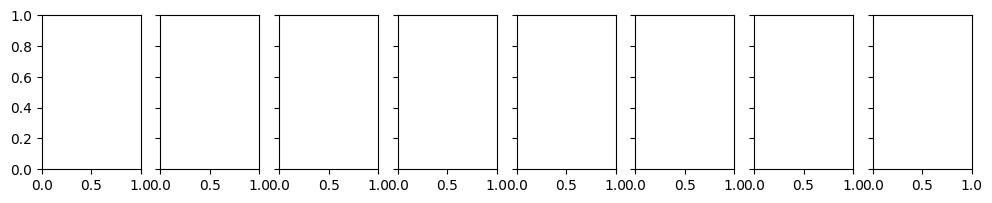

In [ ]:
glm = 1
atlas = 'ROI'
H = 'L'
rois = im.rois[atlas]
df_hrf = pd.read_csv(os.path.join(pth.baseDir, 'hrf', f'hrf.glm{glm}.{atlas}.tsv'), sep='\t',)
df_hrfH = df[df.Hem==H].reset_index()
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(12, 2))
plot_hrf_cut(fig, axs, df_hrfH, rois)
for ax in axs:
    ax.set_xlim(-6, 18)
    ax.spines['left'].set_bounds(0, 2)
    ax.spines['bottom'].set_bounds(0, 18)

plt.show()

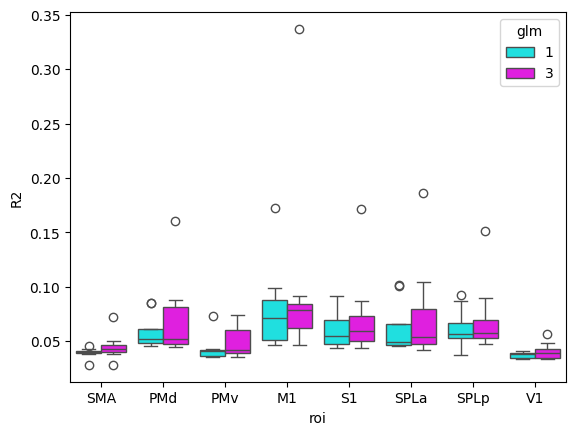

In [71]:
df_R2 = pd.read_csv(os.path.join(pth.baseDir, 'hrf', f'R2.{atlas}.tsv'), sep='\t')
df_R2H = df_R2[df_R2.Hem == H]

fig, ax = plt.subplots()
sb.boxplot(data=df_R2H, ax=ax, x='roi', hue='glm', y='R2', palette=['cyan', 'magenta'])

plt.show()

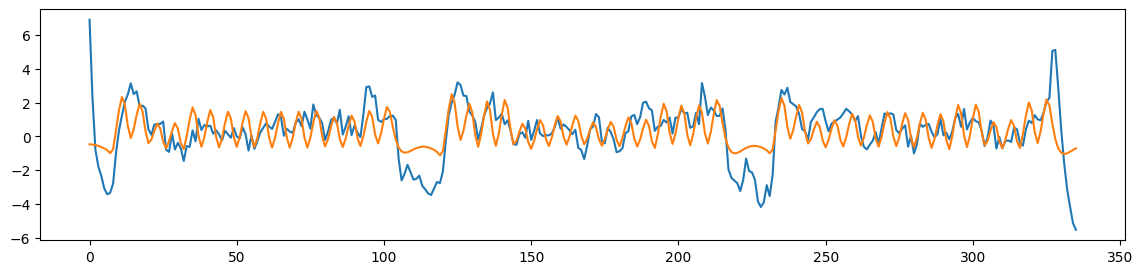

In [72]:
sn = 106

H = 'L'
roi = 'M1'
TR = 1
nTR = 336

# load onset
pinfo = pd.read_csv(os.path.join(pth.baseDir, 'participants.tsv'), sep='\t')
func_runs = pinfo.loc[pinfo.participant_id == f"subj{sn}", "FuncRuns_day3"].iloc[0].split('.')
func_runs = np.array(func_runs, dtype=int)
func_runs = np.array([func_runs + func_runs.size * i for i in range(3)]).flatten()
events = pd.read_csv(os.path.join(pth.baseDir, pth.behavDir, 'day3', f'efc4_subj{sn}_glm{glm}_events.tsv'), sep='\t')
events = events[events.BN.isin(func_runs)]
BN = events.BN.to_numpy() - 1
onset_b = events.Onset.to_numpy()
onset = (np.round(onset_b * TR) + BN * nTR).astype(int)
onset = np.sort(onset)

y_adj,  y_hat = [], []
y_adj = np.load(os.path.join(pth.baseDir, 'hrf', f'subj{sn}', f'y_adj.glm{glm}.ROI.{H}.{roi}.npy'))
y_hat = np.load(os.path.join(pth.baseDir, 'hrf', f'subj{sn}', f'y_hat.glm{glm}.ROI.{H}.{roi}.npy'))
y_adj_bl = np.array(np.split(y_adj, y_adj.shape[0] // nTR, axis=0))
y_hat_bl = np.array(np.split(y_hat, y_hat.shape[0] // nTR, axis=0))

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(y_adj_bl.mean(axis=(0, 2)))
ax.plot(y_hat_bl.mean(axis=(0, 2)))
plt.show()